In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [65]:
# Check shape
print("Shape:", df.shape)

# Check missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

Shape: (45211, 17)
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [66]:
df.columns = df.columns.str.lower().str.replace("-", "_")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [67]:
df['funnel_stage'] = df['y'].apply(lambda x: 'customer' if x == 'yes' else 'lead')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,funnel_stage
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,lead
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,lead
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,lead
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,lead
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,lead


In [70]:
total_leads = len(df)
customers = len(df[df['y'] == 'yes'])

conversion_rate = (customers / total_leads) * 100

print("Total Leads:", total_leads)
print("Customers:", customers)
print("Conversion Rate: {:.2f}%".format(conversion_rate))

Total Leads: 45211
Customers: 5289
Conversion Rate: 11.70%


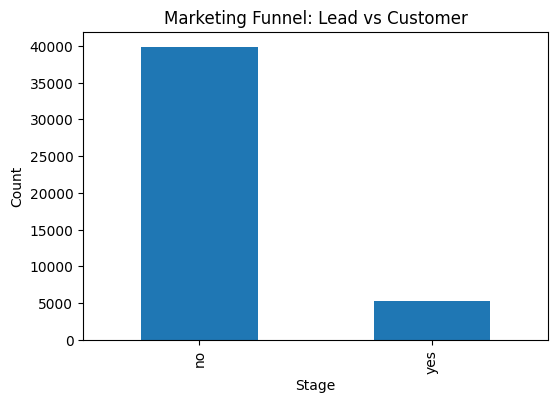

In [88]:
funnel_data = df['y'].value_counts()

plt.figure(figsize=(6,4))
funnel_data.plot(kind='bar')
plt.title("Marketing Funnel: Lead vs Customer")
plt.xlabel("Stage")
plt.ylabel("Count")
plt.show()

In [74]:
job_conversion = pd.crosstab(df['job'], df['y'], normalize='index') * 100
job_conversion = job_conversion.sort_values(by='yes', ascending=False)

print(job_conversion)

y                     no        yes
job                                
student        71.321962  28.678038
retired        77.208481  22.791519
unemployed     84.497314  15.502686
management     86.244449  13.755551
admin.         87.797331  12.202669
self-employed  88.157061  11.842939
unknown        88.194444  11.805556
technician     88.943004  11.056996
services       91.116996   8.883004
housemaid      91.209677   8.790323
entrepreneur   91.728312   8.271688
blue-collar    92.725031   7.274969


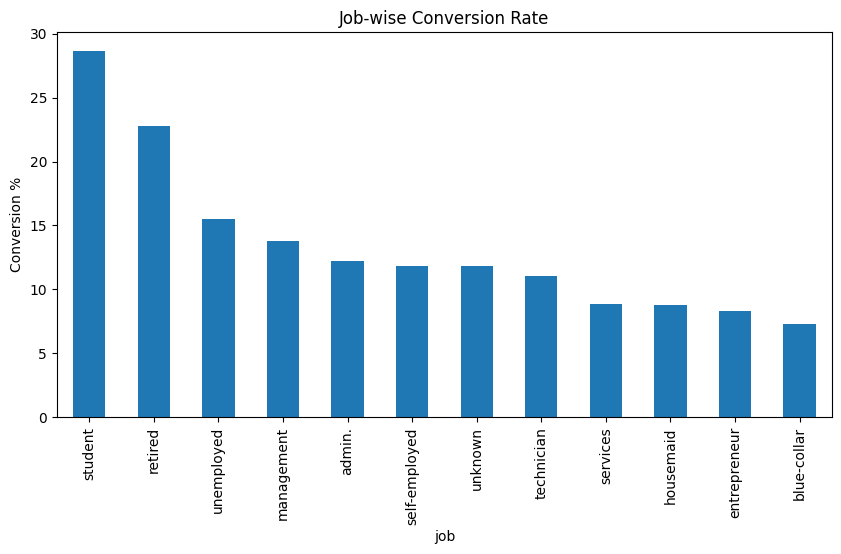

In [77]:
job_conversion['yes'].plot(kind='bar', figsize=(10,5))
plt.title("Job-wise Conversion Rate")
plt.ylabel("Conversion %")
plt.show()

In [79]:
contact_conversion = pd.crosstab(df['contact'], df['y'], normalize='index') * 100

print(contact_conversion)

y                 no        yes
contact                        
cellular   85.081100  14.918900
telephone  86.579491  13.420509
unknown    95.929339   4.070661


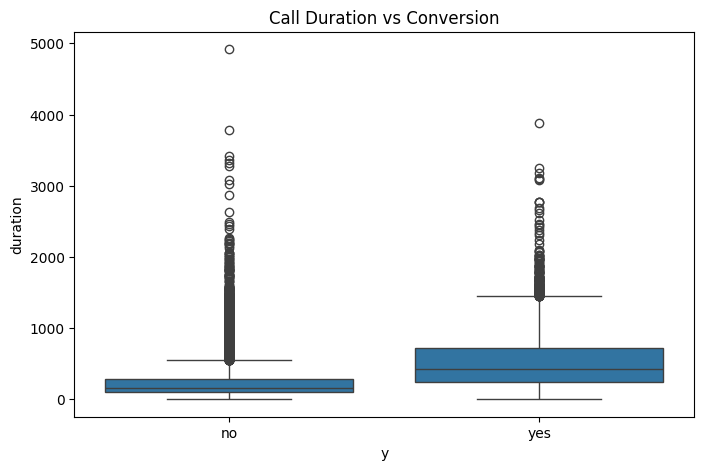

In [81]:
plt.figure(figsize=(8,5))
sns.boxplot(x='y', y='duration', data=df)
plt.title("Call Duration vs Conversion")
plt.show()

In [84]:
campaign_effect = df.groupby('campaign')['y'].value_counts(normalize=True).unstack()

print(campaign_effect)

y               no       yes
campaign                    
1         0.854024  0.145976
2         0.887965  0.112035
3         0.888064  0.111936
4         0.909994  0.090006
5         0.921202  0.078798
6         0.928737  0.071263
7         0.936054  0.063946
8         0.940741  0.059259
9         0.935780  0.064220
10        0.947368  0.052632
11        0.920398  0.079602
12        0.974194  0.025806
13        0.954887  0.045113
14        0.956989  0.043011
15        0.952381  0.047619
16        0.974684  0.025316
17        0.913043  0.086957
18        1.000000       NaN
19        1.000000       NaN
20        0.976744  0.023256
21        0.971429  0.028571
22        1.000000       NaN
23        1.000000       NaN
24        0.950000  0.050000
25        1.000000       NaN
26        1.000000       NaN
27        1.000000       NaN
28        1.000000       NaN
29        0.937500  0.062500
30        1.000000       NaN
31        1.000000       NaN
32        0.888889  0.111111
33        1.00

In [86]:
df['age_group'] = pd.cut(df['age'], bins=[0,25,40,60,100], labels=['Young','Adult','Senior','Old'])

age_conversion = pd.crosstab(df['age_group'], df['y'], normalize='index') * 100

print(age_conversion)

y                 no        yes
age_group                      
Young      76.047904  23.952096
Adult      88.721612  11.278388
Senior     90.521082   9.478918
Old        57.744108  42.255892


In [87]:
df.to_csv("clean_bank_funnel.csv", index=False)